# Reflection Spectra over Frequencies for Radar Design

This notebook is 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import os
import re

Now, the appropriate functions are defined (parsecomplexsafe, getfreq)

In [25]:
# Parse complex safe
def parse_complex_safe(s):
    """
    Parse a string from a PDF table into a complex number.
    Handles weird cases like '1.6503+', '2.34- 0.56i', etc.
    """
    if s is None:
        return complex(0, 0)
    
    s = s.strip()  # remove leading/trailing whitespace
    s = s.replace(" ", "")  # remove internal spaces
    s = s.replace('\n', '') # remove internal line breaks
    s = s.replace("i", "j")  # Python uses j for imaginary unit
    s = s.replace('–', '-') # adjusts dash type (em to en)

    # Fix cases where string ends with + or - (incomplete imaginary part)
    if re.match(r"^[+-]?[\d.]+[+-]$", s):
        s += "0j"  # add 0 as imaginary part
    
    # Fix cases where string is just a real number with trailing j
    if re.match(r"^[+-]?[\d.]+$", s):
        s += "+0j"

    try:
        c = complex(s)
    except ValueError:
        # fallback: treat as 0+0j
        c = complex(0, 0)
    return c

In [26]:
# Get frequency range
def get_frequency_range_from_pdf(material, pdf_path):
    '''
    Extracts the frequency range (min, max) for a given material
    from the PDF text.
    '''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            for line in text.split("\n"):
                if material.lower() in line.lower():
                    # Look for (X–Y GHz) after the material name
                    match = re.search(r"\((\d*\.?\d+)–(\d*\.?\d+)\s*GHz\)", line)
                    if match:
                        f_min = float(match.group(1))
                        f_max = float(match.group(2))
                        return f_min, f_max
    return None, None

Functions for gettting epsilon and mu values for 12_1, 12_4, 12_6, 12_7, 12_8 are defined

Working: 12_1, 12_6, 12_8 (mostly)

Not yet working (error placeholder): 12_4, 12_7

In [27]:
# 12_1
def getEpAndMu_12_1(user_f_min, user_f_max, material, value):
    if (value == 'Sample ID'):
        return ValueError
    
    if (value == ''):
        return ValueError
    
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_1.pdf")

    rows = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        # print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    #if user_f_min < f_min or user_f_max > f_max:
        #print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]


    # Apply to the selected row
    real_floats = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe).apply(lambda x: x.real)
    imag_floats = df_selected.iloc[sample_idx].apply(parse_complex_safe).apply(lambda x: x.imag)

    complex_floats = real_floats + imag_floats * complex(0, 1)
    complex_floats.head()

    B = complex_floats.iloc[0]
    C = complex_floats.iloc[1]
    D = complex_floats.iloc[2]
    G = complex_floats.iloc[3]
    H = complex_floats.iloc[4]
    I = complex_floats.iloc[5]
    J = complex_floats.iloc[6]
    
    num_points = 1000  # Number of frequency points
   
    frequencies = np.linspace(user_f_min, user_f_max, num_points)
    epsilon_f = B + 2 * C * (frequencies ** D) + G * (1 - J * (frequencies - H)**2 - 1j * 2 * I * frequencies)**(-1)


    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title(f'{value}', fontsize=14)
    plt.xlim(f_min, f_max)
    plt.ylim(1e-4, 1e5)
    plt.savefig(f"{value}.png") 
    plt.show()

    # return values
    #return(epsilon_f, mu_f)

In [28]:
# 12_4
def getEpAndMu_12_4(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

In [29]:
# 12_6
def getEpAndMu_12_6(user_f_min, user_f_max, material, value):
    if (value == 'B'):
        return ValueError
    
    if (value == ''):
        return ValueError

    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_6.pdf")

    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    


    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)
    # Convert single string into complex float
    df_selected = df[["B", "C", "D", "E", "F", "G", "H"]]

    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    E = complex(values.iloc[3])
    F = complex(values.iloc[4])
    G = complex(values.iloc[5])
    H = complex(values.iloc[6])

    #define frequency range

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + np.real(C) * (frequencies ** D) + np.imag(C) * (frequencies ** E) + F * (1 - (frequencies / G) ** 2 - 1j * 2 * frequencies / H) ** (-1))

    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e5)
    plt.show()

    # return values
    #return(epsilon_f, mu_f)

In [30]:
# 12_7 WORK TO BE DONE
def getEpAndMu_12_7(user_f_min, user_f_max, material):
    error = 1/0 # error placeholder
    return

In [31]:
# 12_8
# Works except for final material - will need to add on or hardcode
def getEpAndMu_12_8(user_f_min, user_f_max, material, value):
    base_dir = os.getcwd()
    pdf_path = os.path.join(base_dir, "12_8.pdf")

    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]

    # Acquire real and imag components - for this section they are combined
    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    G = complex(values.iloc[3])
    H = complex(values.iloc[4])
    I = complex(values.iloc[5])
    J = complex(values.iloc[6])

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + (2*C*(frequencies**D)) + (G*(1 - (J *(frequencies - H)**2) - (1j*2*I*frequencies))**-1))

    #permeability (mu = 1 for non-ferrous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title(f'{value}', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e5)
    plt.show()

    # return values
    return(epsilon_f, mu_f)

Now, the user is asked for the material, low frequency range, and high frequency range

C:\Users\josh4\AppData\Local\Temp\ipykernel_47260\2659881964.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]


Material error
Material error


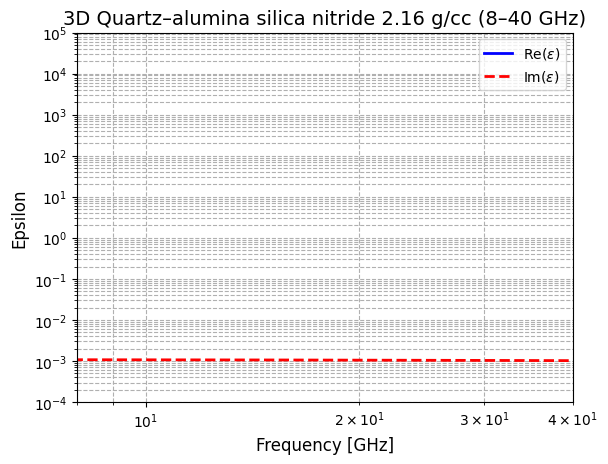

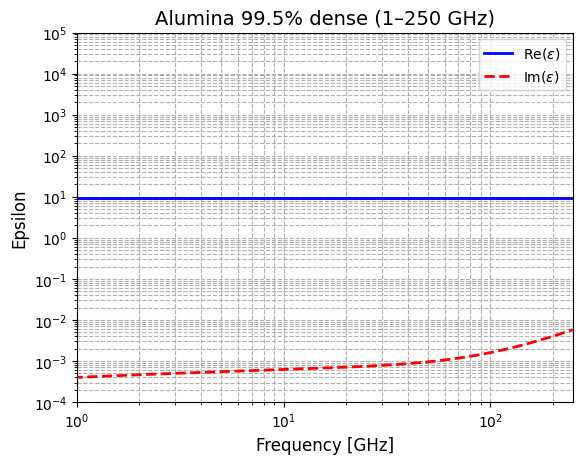

Material error
Material error
Material error


C:\Users\josh4\AppData\Local\Temp\ipykernel_47260\2659881964.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]


Material error


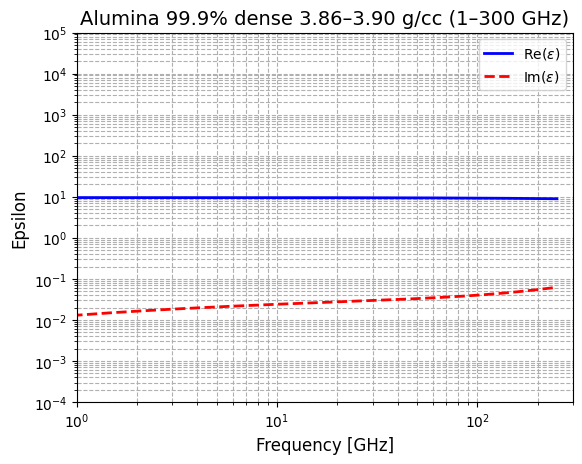

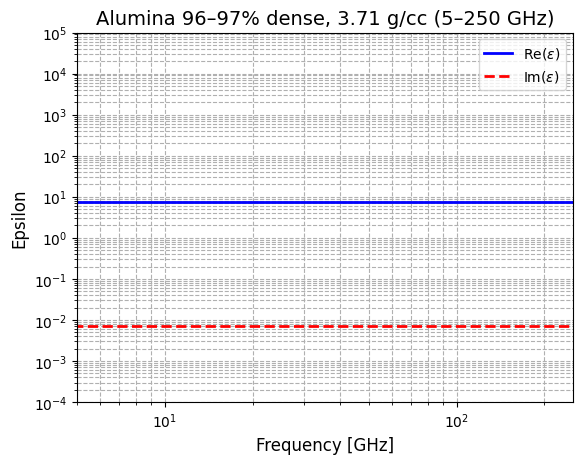

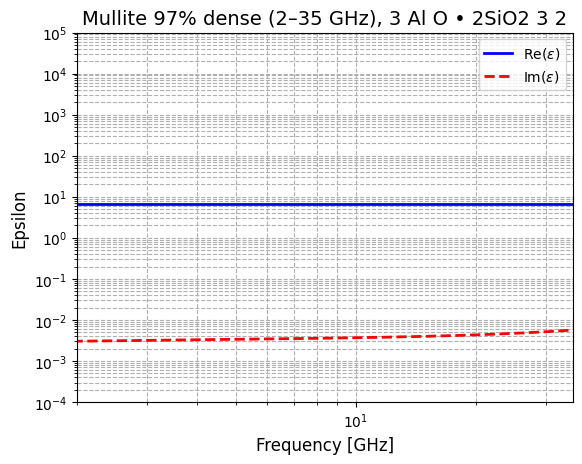

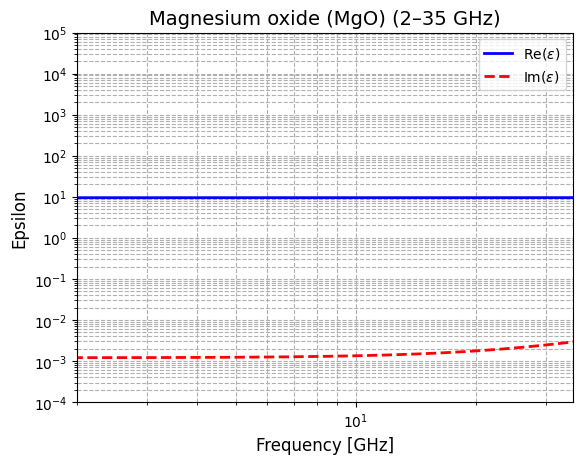

Material error


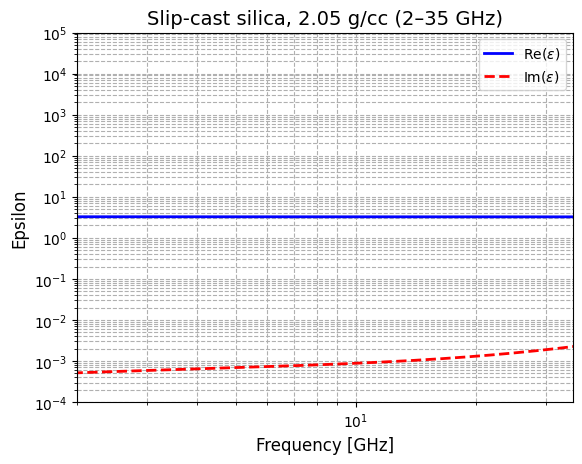

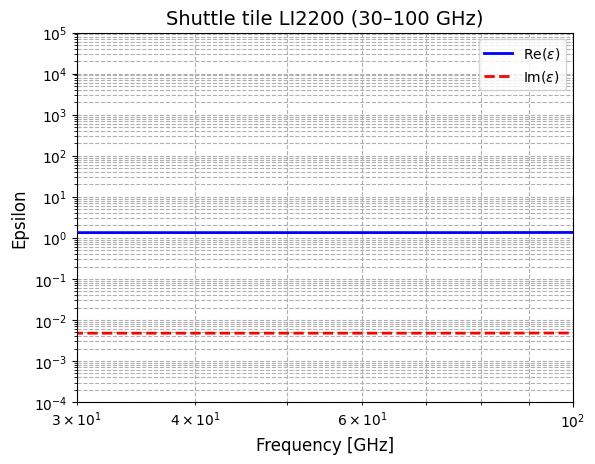

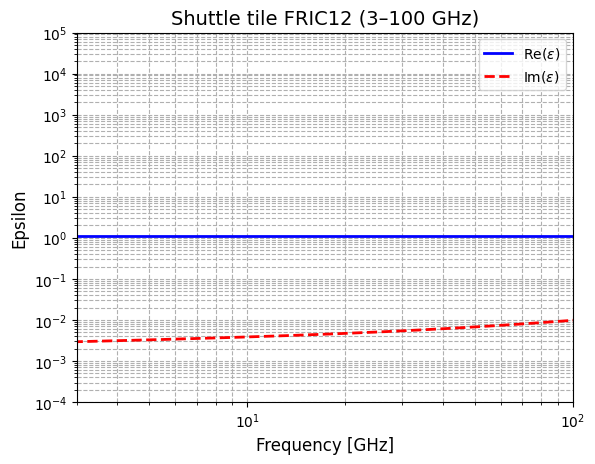

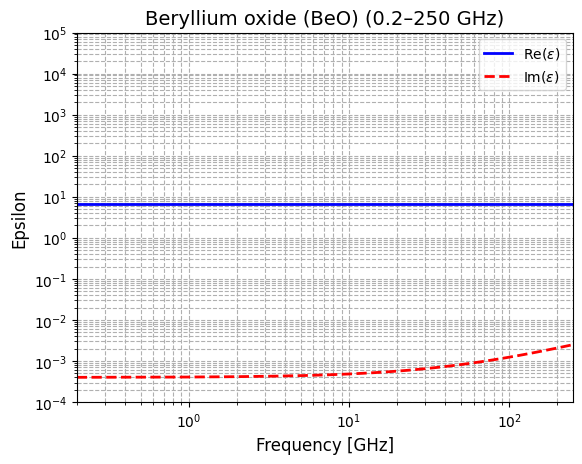

Material error


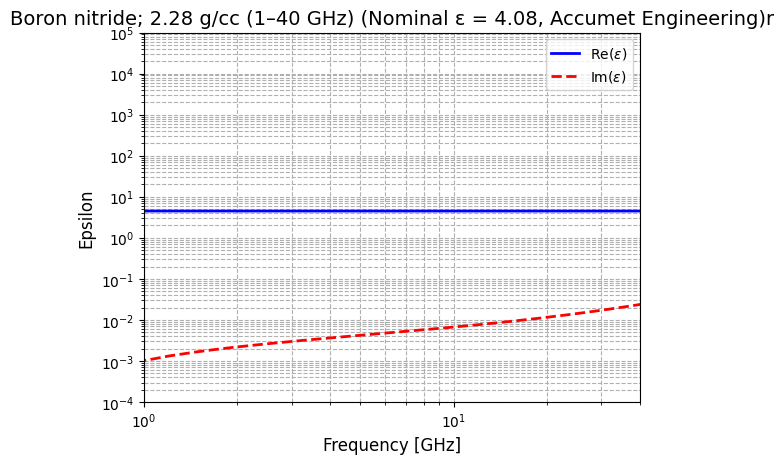

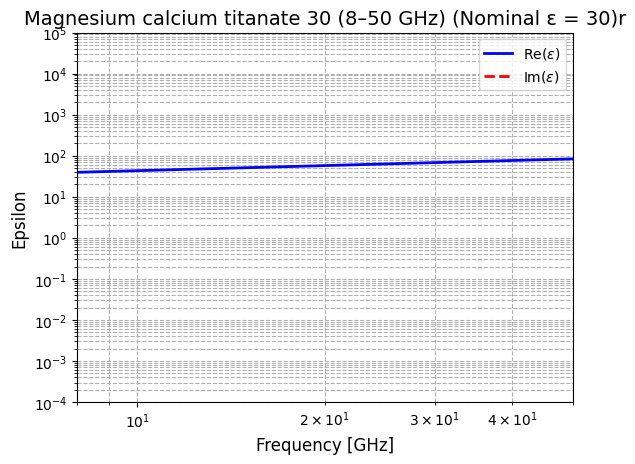

C:\Users\josh4\AppData\Local\Temp\ipykernel_47260\2659881964.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]


Material error


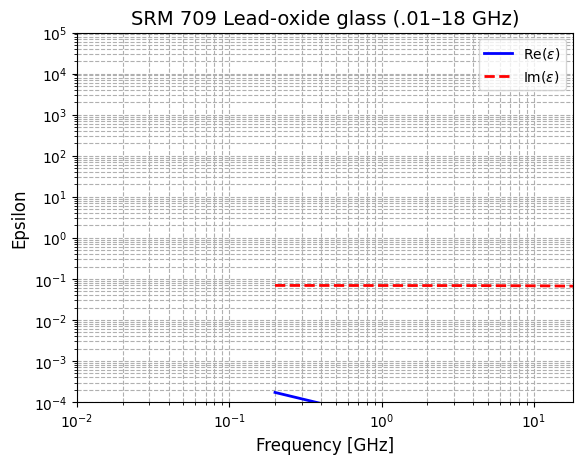

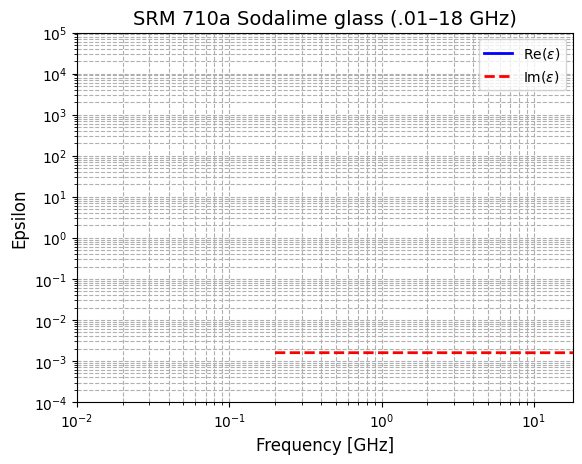

Material error
Material error
Material error
Material error


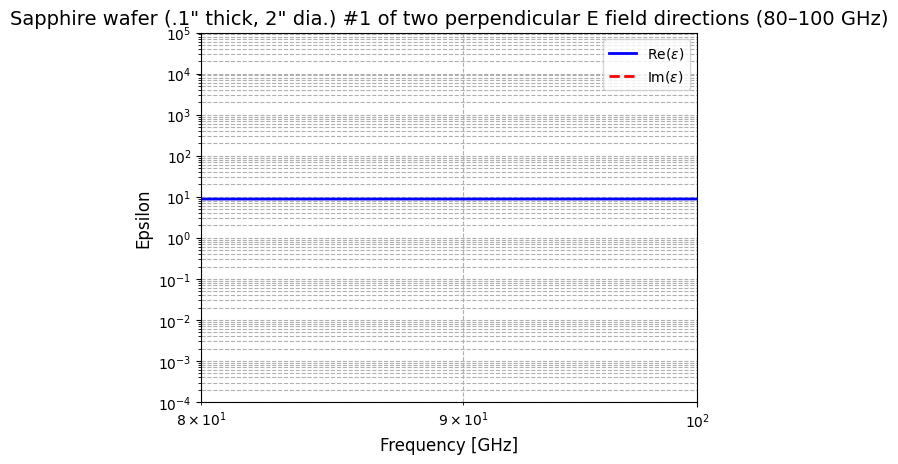

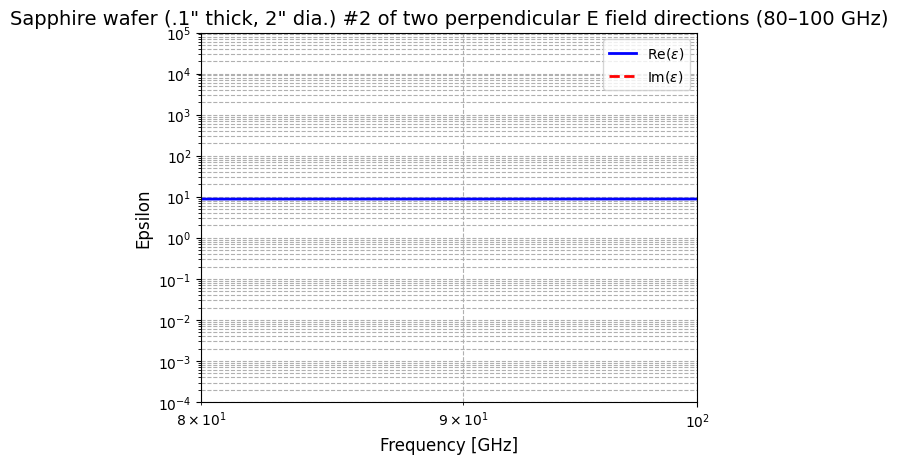

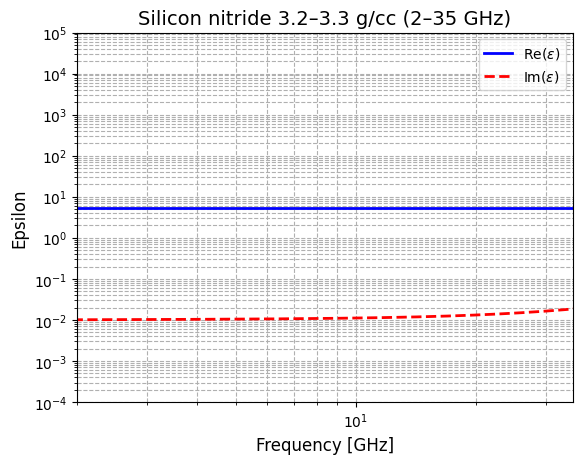

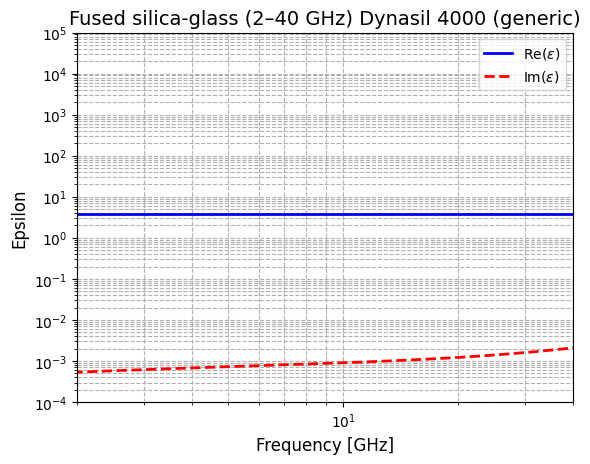

Material error


C:\Users\josh4\AppData\Local\Temp\ipykernel_47260\2659881964.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]


Material error


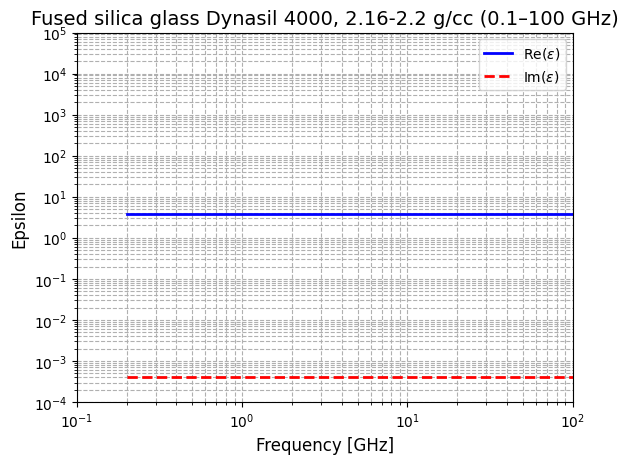

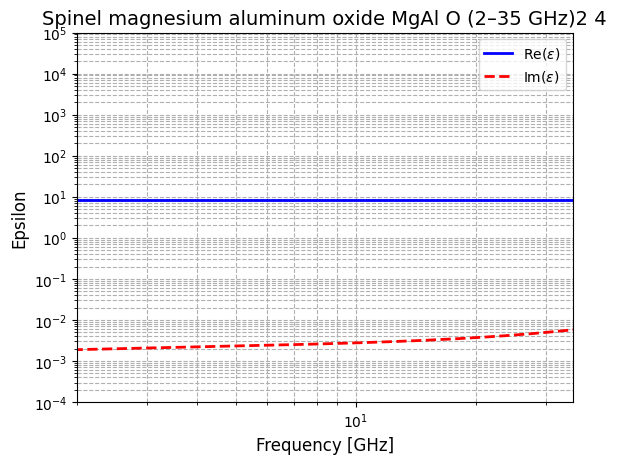

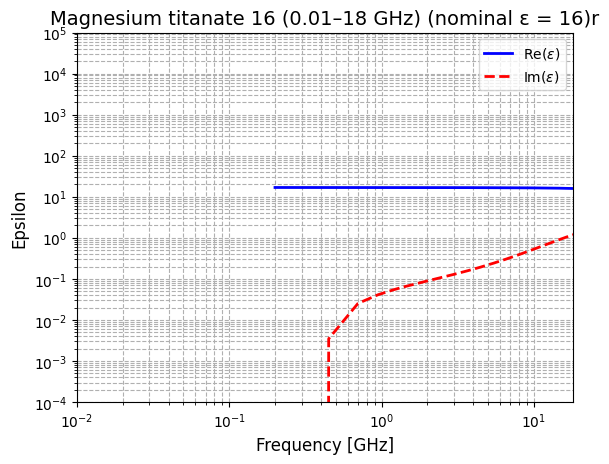

Material error
Material error
Material error
Material error
Material error
Material error


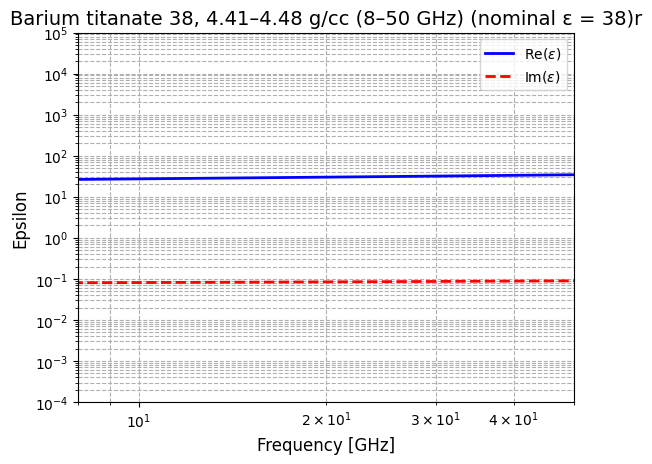

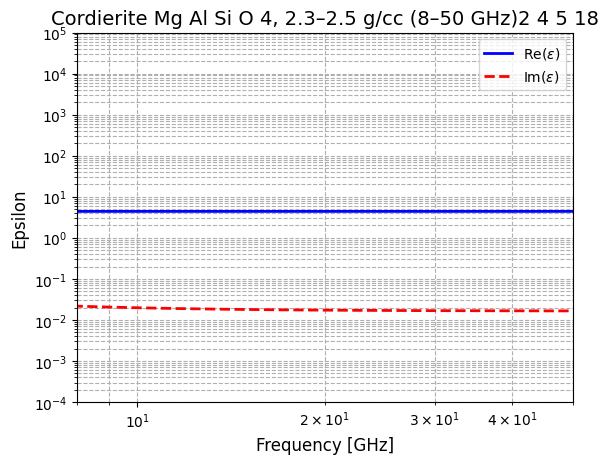

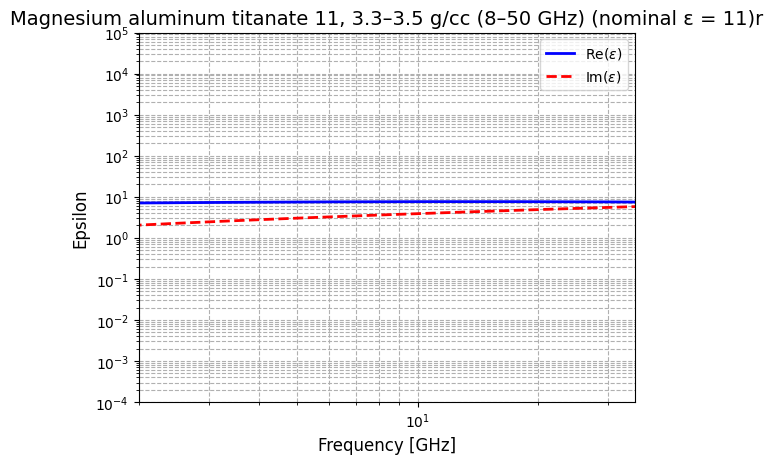

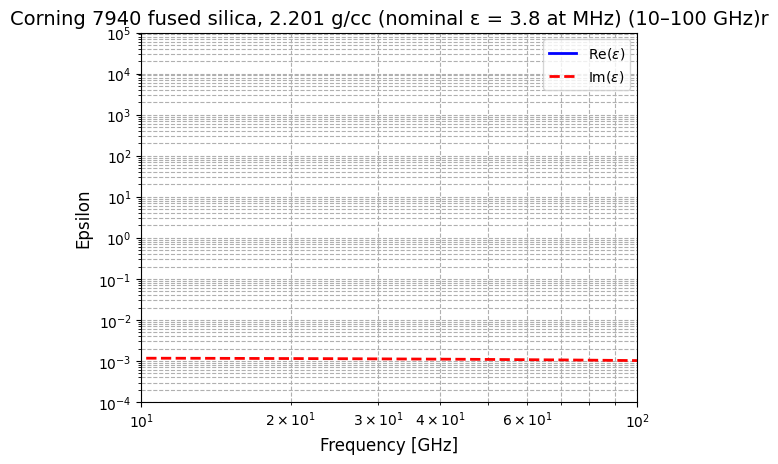

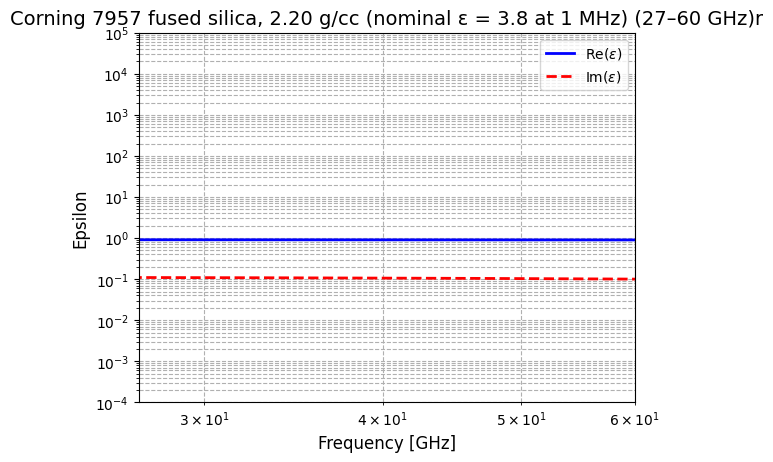

In [32]:
# Save plot for 12_1
base_dir = os.getcwd()
pdf_path = os.path.join(base_dir, "12_1.pdf")

rows = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        if table:
            rows.extend(table)

df = pd.DataFrame(rows)
material_list=df.iloc[:,0]

#print(material_list)


for value in material_list:
    value = value.replace('\n', '')
    material = str(value)
    material = material[:15]
    #print(material)
    try: 
        getEpAndMu_12_1(0.2, 250, material, value)
    except Exception as e:
        print('Material error')